# Demo of quantum-classic hybird circuit

## Preparation

1. import numpy and pandas
1. prepare matplotlib for drawing
1. import qiskit and display its version table

In [1]:
# Import necessary data-processing modules
import numpy as np
import pandas as pd

# Control matplotlib style (white background)
%matplotlib inline
from matplotlib import style
import matplotlib.pyplot as plt
for s in plt.style.available:
    if s.startswith('seaborn') and s.endswith('white'):
        style.use(s)
        break

# Import QisKit
import qiskit
import qiskit.tools.jupyter
%qiskit_version_table


## Prepare hybird circuit

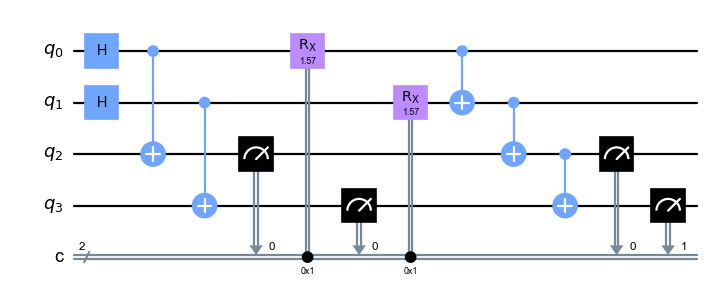

In [18]:
qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[4];
creg c[2];

h q[0];
h q[1];

cx q[0], q[2];
cx q[1], q[3];

measure q[2] -> c[0];
if (c == 1) rx(1.570796) q[0];

measure q[3] -> c[0];
if (c == 1) rx(1.570796) q[1];

cx q[0], q[1];
cx q[1], q[2];
cx q[2], q[3];

measure q[2] -> c[0];
measure q[3] -> c[1];
"""
circ = qiskit.QuantumCircuit.from_qasm_str(qasm)
circ.draw(style='clifford', scale=0.8)


## Try simulate

In [30]:
def simulate_circuit(circuit: qiskit.QuantumCircuit, shots: int = 1000):
    backend = qiskit.providers.basicaer.QasmSimulatorPy()
    transpiled = qiskit.transpile(circuit, backend)
    job = backend.run(transpiled, shots=shots)
    return job.result()


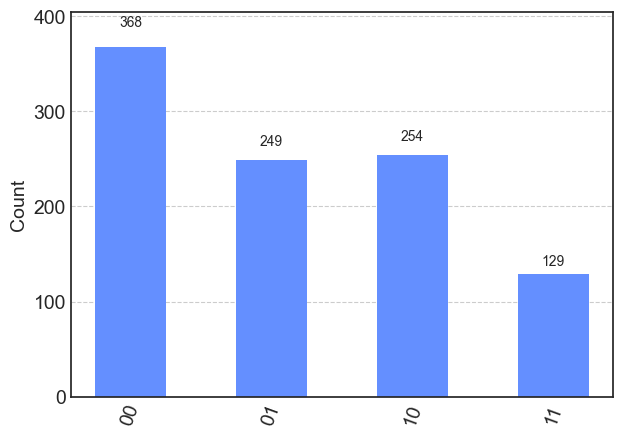

In [31]:
rst = simulate_circuit(circ)
qiskit.visualization.plot_histogram(rst.get_counts())


## Counter part

Same circuit without hybrid operations

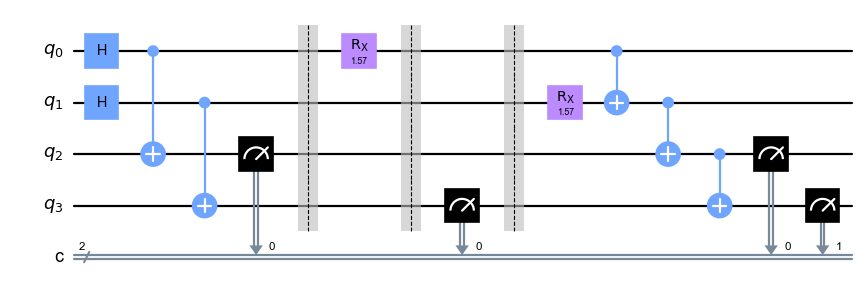

In [21]:
qasm1 = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[4];
creg c[2];

h q[0];
h q[1];

cx q[0], q[2];
cx q[1], q[3];

measure q[2] -> c[0];
barrier q;
rx(1.570796) q[0];

barrier q;
measure q[3] -> c[0];
barrier q;
rx(1.570796) q[1];

cx q[0], q[1];
cx q[1], q[2];
cx q[2], q[3];

measure q[2] -> c[0];
measure q[3] -> c[1];
"""
circ1 = qiskit.QuantumCircuit.from_qasm_str(qasm1)
circ1.draw(style='clifford', scale=0.8)


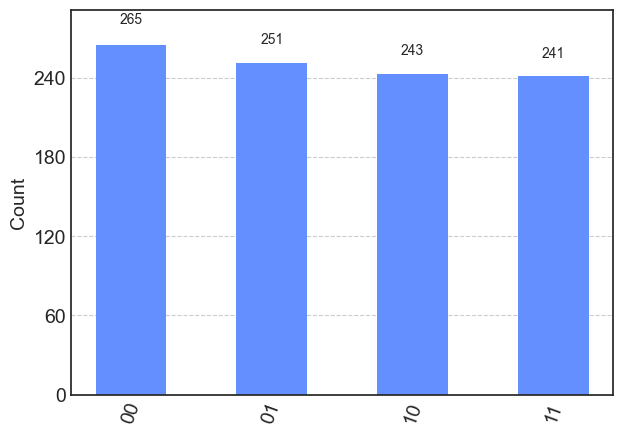

In [32]:
rst = simulate_circuit(circ1)
qiskit.visualization.plot_histogram(rst.get_counts())


## Compare

In [6]:
for op in circ.data:
    print(op)


CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 0),), clbits=())
CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 1),), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 0), Qubit(QuantumRegister(4, 'q'), 2)), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 1), Qubit(QuantumRegister(4, 'q'), 3)), clbits=())
CircuitInstruction(operation=Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 2),), clbits=(Clbit(ClassicalRegister(2, 'c'), 0),))
CircuitInstruction(operation=Instruction(name='rx', num_qubits=1, num_clbits=0, params=[1.570796]), qubits=(Qubit(QuantumRegister(4, 'q'), 0),), clbits=(

In [7]:
for op in circ1.data:
    print(op)


CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 0),), clbits=())
CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 1),), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 0), Qubit(QuantumRegister(4, 'q'), 2)), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 1), Qubit(QuantumRegister(4, 'q'), 3)), clbits=())
CircuitInstruction(operation=Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 2),), clbits=(Clbit(ClassicalRegister(2, 'c'), 0),))
CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 0), Qubit(Quantum

## Common circuit example

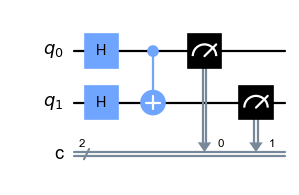

In [17]:
qasm_bell = """
OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q;
cx q[0], q[1];
measure q -> c;
"""
bell = qiskit.QuantumCircuit.from_qasm_str(qasm_bell)
bell.draw(style='clifford', scale=0.8)


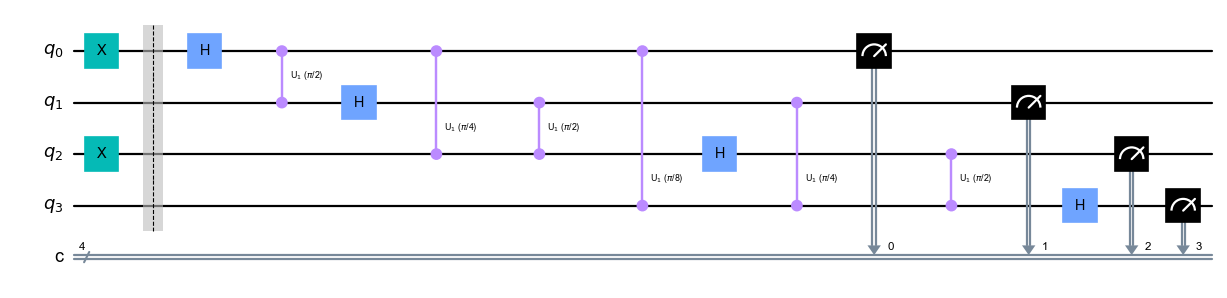

In [41]:
qasm_qft = """
OPENQASM 2.0;
include "qelib1.inc";
qreg q[4];
creg c[4];
x q[0];
x q[2];
barrier q;
h q[0];
cu1(pi/2) q[1],q[0];
h q[1];
cu1(pi/4) q[2],q[0];
cu1(pi/2) q[2],q[1];
h q[2];
cu1(pi/8) q[3],q[0];
cu1(pi/4) q[3],q[1];
cu1(pi/2) q[3],q[2];
h q[3];
measure q -> c;
"""
qft = qiskit.QuantumCircuit.from_qasm_str(qasm_qft)
qft.draw(style='clifford', scale=0.8)


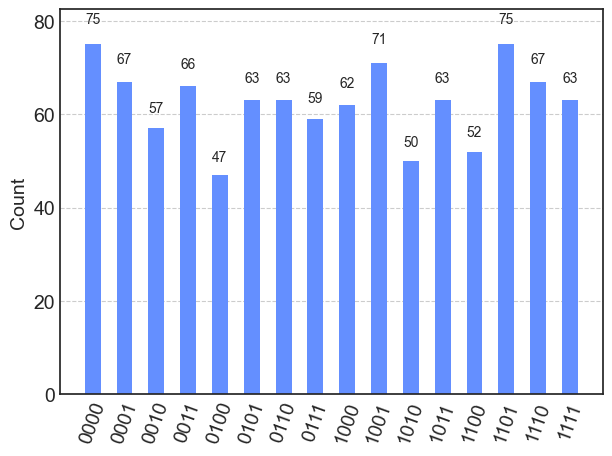

In [42]:
rst = simulate_circuit(qft)
qiskit.visualization.plot_histogram(rst.get_counts())


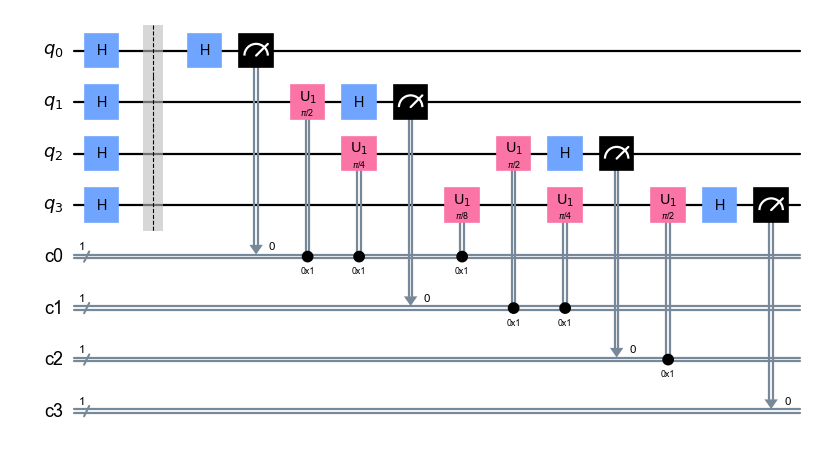

In [45]:
qasm_iqft = """
OPENQASM 2.0;
include "qelib1.inc";
qreg q[4];
creg c0[1];
creg c1[1];
creg c2[1];
creg c3[1];
h q;
barrier q;
h q[0];
measure q[0] -> c0[0];
if(c0==1) u1(pi/2) q[1];
h q[1];
measure q[1] -> c1[0];
if(c0==1) u1(pi/4) q[2];
if(c1==1) u1(pi/2) q[2];
h q[2];
measure q[2] -> c2[0];
if(c0==1) u1(pi/8) q[3];
if(c1==1) u1(pi/4) q[3];
if(c2==1) u1(pi/2) q[3];
h q[3];
measure q[3] -> c3[0];
"""
iqft = qiskit.QuantumCircuit.from_qasm_str(qasm_iqft)
iqft.draw(style='clifford', scale=0.8)


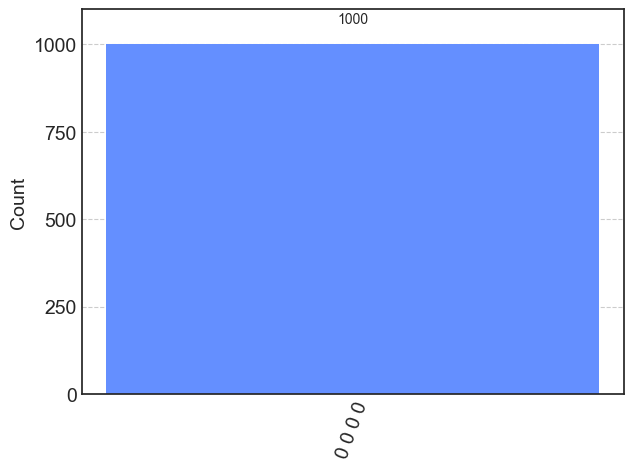

In [46]:
rst = simulate_circuit(iqft)
qiskit.visualization.plot_histogram(rst.get_counts())
